# 📊 Federated Learning - Análisis de Resultados

Este notebook muestra los resultados del entrenamiento Federated Learning utilizando las funciones del dashboard Flask. 

**Demos disponibles:**
1. **Breast Cancer (Tabular)**: Clasificación binaria con datos tabulares (30 features)
2. **Breast Ultrasound (Images)**: Clasificación multiclase con imágenes de ultrasonido (ResNet18 + GPU)

---

## 📂 Fuentes de Datos

Los datasets utilizados en este proyecto son **públicos y de libre acceso** para investigación. No contienen información personal identificable (PII).

### Demo 1 — Breast Cancer (Datos Tabulares)

| Atributo | Detalle |
|---|---|
| **Nombre** | Wisconsin Breast Cancer Dataset |
| **Origen** | UCI Machine Learning Repository |
| **Acceso** | `sklearn.datasets.load_breast_cancer()` |
| **Referencia** | W.N. Street, W.H. Wolberg, O.L. Mangasarian (1993). *Nuclear feature extraction for breast tumor diagnosis.* SPIE Symposium on Electronic Imaging, Vol. 1905, pp. 861–870. |
| **URL** | https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic |
| **Muestras** | 569 (212 malignas, 357 benignas) |
| **Features** | 30 (radio, textura, perímetro, área, suavidad, etc.) |
| **Licencia** | Creative Commons Attribution 4.0 (CC BY 4.0) — libre uso para investigación |

### Demo 2 — Breast Ultrasound Images (Imágenes)

| Atributo | Detalle |
|---|---|
| **Nombre** | Breast Ultrasound Images Dataset (BUSI) |
| **Origen** | Kaggle — Al-Dhabyani et al. |
| **Referencia** | Al-Dhabyani W., Gomaa M., Khaled H., Fahmy A. (2020). *Dataset of breast ultrasound images.* Data in Brief, 28, 104863. DOI: [10.1016/j.dib.2019.104863](https://doi.org/10.1016/j.dib.2019.104863) |
| **URL** | https://www.kaggle.com/datasets/aryashah2k/breast-ultrasound-images-dataset |
| **Imágenes** | 780 imágenes de ultrasonido con máscaras de segmentación |
| **Clases** | `benign` (437), `malignant` (210), `normal` (133) |
| **Licencia** | Uso académico y de investigación — se requiere citar la publicación original |

> **Nota de privacidad:** Ambos datasets son anonimizados y no contienen información personal identificable. Los datos de imágenes fueron procesados en nodos locales simulando hospitales; **los datos crudos nunca salen del nodo local** (principio de Federated Learning). Solo se comparten gradientes del modelo.

---

## 📦 1. Importar Librerías y Funciones

Reutilizamos las funciones del archivo `dashboard_flask_cancer.py` para cargar datos y generar visualizaciones.

In [33]:
# Configurar rutas del proyecto
import sys
import os
from pathlib import Path

# Agregar raíz del proyecto al path
project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(project_root))
sys.path.insert(0, str(project_root / "scripts" / "python"))

print(f"📁 Proyecto: {project_root}")

# Calcular PROJECT_ROOT para usar en funciones de carga
PROJECT_ROOT = project_root

# Librerías estándar
import json
import pandas as pd
import plotly.graph_objs as go
from IPython.display import display, HTML

# Importar funciones desde dashboard_flask_cancer.py
from dashboard_flask_cancer import (
    load_training_history,
    create_convergence_plot,
    create_comparison_plot,
    create_confusion_matrix_plot,
    create_false_negatives_plot,
    create_hospital_evolution_plot,
    create_timing_plot,
    create_refined_comparison_plot,
    extract_gpu_metrics,
    DEMOS_CONFIG
)

print("✅ Librerías importadas correctamente")
print(f"\n📋 Demos disponibles: {list(DEMOS_CONFIG.keys())}")
# Recargar módulo si ya estaba importado (para desarrollo)
import importlib
import dashboard_flask_cancer
importlib.reload(dashboard_flask_cancer)
# Reimportar después de reload
from dashboard_flask_cancer import (
    load_training_history,
    create_convergence_plot,
    create_comparison_plot,
    create_confusion_matrix_plot,
    create_false_negatives_plot,
    create_hospital_evolution_plot,
    create_timing_plot,
    create_refined_comparison_plot,
    extract_gpu_metrics,

    DEMOS_CONFIG

)
print("🔄 Módulo recargado (incluye corrección de project_root)")

📁 Proyecto: /mnt/c/Users/mikes/source/repos/TestFML
✅ Librerías importadas correctamente

📋 Demos disponibles: ['cancer', 'ultrasound']
📁 Raíz del proyecto: /mnt/c/Users/mikes/source/repos/TestFML
🔄 Módulo recargado (incluye corrección de project_root)


## 🔧 2. Configuración

Selecciona el demo que deseas analizar:
- `'cancer'`: Datos tabulares (Breast Cancer)
- `'ultrasound'`: Imágenes de ultrasonido (con GPU)

In [34]:
# Seleccionar demo
DEMO_TYPE = 'ultrasound'  # Cambiar a 'cancer' para ver el otro demo

# Obtener configuración del demo
demo_config = DEMOS_CONFIG[DEMO_TYPE]

print(f"📊 Demo seleccionado: {demo_config['name']}")
print(f"📝 Descripción: {demo_config['description']}")
print(f"🎯 Tipo de métricas: {demo_config['metrics_type']}")
print(f"📦 Clases: {demo_config['classes']}")

📊 Demo seleccionado: Breast Ultrasound (Images)
📝 Descripción: Clasificación multiclase con imágenes de ultrasonido
🎯 Tipo de métricas: multiclass
📦 Clases: ['Benign', 'Malignant', 'Normal']


## 📥 3. Cargar Datos del Entrenamiento

Cargamos el historial de entrenamiento desde el archivo JSON generado durante el entrenamiento.

In [35]:
# Cargar historial usando la función del dashboard
print("🔍 DEBUG - Información de rutas:")
print(f"  📁 project_root (notebook): {project_root}")
print(f"  📁 PROJECT_ROOT (local): {PROJECT_ROOT}")
print(f"  📄 DEMO_TYPE: {DEMO_TYPE}")
print(f"  📄 Archivo esperado: {demo_config['file']}")
print(f"  📂 Ruta completa: {PROJECT_ROOT / demo_config['file']}")
print(f"  ✓ ¿Archivo existe?: {(PROJECT_ROOT / demo_config['file']).exists()}")

# Listar archivos JSON en la raíz para verificar
print(f"\n📂 Archivos JSON en {PROJECT_ROOT}:")
import os
json_files = [f for f in os.listdir(PROJECT_ROOT) if f.endswith('.json') and 'training_history' in f]
for jf in json_files:
    print(f"  ✓ {jf}")
print()

# CRÍTICO: Pasar PROJECT_ROOT como parámetro
print("🔄 Llamando a load_training_history() con project_root...")
history = load_training_history(DEMO_TYPE, project_root=PROJECT_ROOT)

if history is None:
    print("❌ No se encontraron datos de entrenamiento")
    print(f"💡 La función load_training_history() retornó None")
else:
    print(f"✅ Historial cargado: {len(history)} entradas")
    print(f"📊 Archivo: {demo_config['file']}")
    print(f"\n🔢 Fases detectadas:")
    for entry in history:
        phase = entry.get('phase', 'fl_training')
        round_num = entry.get('round', 0)
        print(f"  - Round {round_num}: {phase}")


🔍 DEBUG - Información de rutas:
  📁 project_root (notebook): /mnt/c/Users/mikes/source/repos/TestFML
  📁 PROJECT_ROOT (local): /mnt/c/Users/mikes/source/repos/TestFML
  📄 DEMO_TYPE: ultrasound
  📄 Archivo esperado: training_history_ultrasound_nvflare.json
  📂 Ruta completa: /mnt/c/Users/mikes/source/repos/TestFML/training_history_ultrasound_nvflare.json
  ✓ ¿Archivo existe?: True

📂 Archivos JSON en /mnt/c/Users/mikes/source/repos/TestFML:
  ✓ training_history_cancer_nvflare.json
  ✓ training_history_ultrasound_nvflare.json

🔄 Llamando a load_training_history() con project_root...
✅ Archivo cargado exitosamente: /mnt/c/Users/mikes/source/repos/TestFML/training_history_ultrasound_nvflare.json (7 entradas)
✅ Historial cargado: 7 entradas
📊 Archivo: training_history_ultrasound_nvflare.json

🔢 Fases detectadas:
  - Round 0: fl_training
  - Round 1: fl_training
  - Round 2: fl_training
  - Round 3: fl_training
  - Round 4: fl_training
  - Round 5: fl_training
  - Round 6: fine_tuning


## 📈 4. Métricas Globales

Analizamos las métricas del modelo global al final del entrenamiento.

In [36]:
if history:
    # Obtener última entrada de FL training
    fl_entries = [e for e in history if e.get('phase') == 'fl_training']
    last_fl = fl_entries[-1] if fl_entries else history[-1]
    
    gm = last_fl['global_metrics']
    metrics_type = demo_config['metrics_type']
    
    print("=" * 70)
    print("📊 MÉTRICAS DEL MODELO GLOBAL")
    print("=" * 70)
    print(f"Round: {last_fl['round']}")
    print(f"Accuracy: {gm['accuracy']*100:.2f}%")
    
    if metrics_type == 'binary':
        print(f"Sensitivity: {gm['sensitivity']*100:.2f}%")
        print(f"Specificity: {gm['specificity']*100:.2f}%")
        print(f"\nMatriz de confusión:")
        print(f"  TP (Verdaderos Positivos): {gm.get('tp', 0)}")
        print(f"  TN (Verdaderos Negativos): {gm.get('tn', 0)}")
        print(f"  FP (Falsos Positivos): {gm.get('fp', 0)}")
        print(f"  FN (Falsos Negativos): {gm.get('fn', 0)}")
    else:
        print(f"\n📊 Métricas por clase:")
        if 'class_metrics' in gm:
            for class_name, metrics in gm['class_metrics'].items():
                print(f"\n  {class_name.upper()}:")
                print(f"    Precision: {metrics['precision']*100:.2f}%")
                print(f"    Recall: {metrics['recall']*100:.2f}%")
                print(f"    F1-Score: {metrics['f1']*100:.2f}%")
    
    print("=" * 70)

📊 MÉTRICAS DEL MODELO GLOBAL
Round: 5
Accuracy: 70.79%

📊 Métricas por clase:

  CLASS_0:
    Precision: 92.57%
    Recall: 76.97%
    F1-Score: 84.05%

  CLASS_1:
    Precision: 94.29%
    Recall: 39.29%
    F1-Score: 55.46%

  CLASS_2:
    Precision: 40.15%
    Recall: 100.00%
    F1-Score: 57.30%


## 🏥 5. Métricas de Hospitales (Fine-Tuning)

Comparamos el rendimiento de cada hospital después del refinamiento local.

In [37]:
if history:
    # Buscar entrada de fine-tuning
    ft_entries = [e for e in history if e.get('phase') == 'fine_tuning']
    
    if ft_entries:
        ft_entry = ft_entries[-1]
        refined_models = ft_entry.get('refined_models', [])
        
        print("=" * 70)
        print("🏥 RESULTADOS POR HOSPITAL (DESPUÉS DE FINE-TUNING)")
        print("=" * 70)
        
        # Crear DataFrame para visualizar mejor
        data = []
        for model in refined_models:
            hospital_id = model['client_id']
            accuracy = model['accuracy'] * 100
            ft_time = model.get('finetune_time', 0)
            
            data.append({
                'Hospital': f"Hospital {hospital_id}",
                'Accuracy (%)': round(accuracy, 2),
                'Fine-tuning Time (s)': round(ft_time, 2)
            })
        
        df_hospitals = pd.DataFrame(data)
        display(df_hospitals)
        
        print(f"\n📊 Accuracy promedio: {df_hospitals['Accuracy (%)'].mean():.2f}%")
        print(f"🏆 Mejor hospital: {df_hospitals.loc[df_hospitals['Accuracy (%)'].idxmax(), 'Hospital']} con {df_hospitals['Accuracy (%)'].max():.2f}%")
    else:
        print("⚠️ No se encontraron datos de fine-tuning")

🏥 RESULTADOS POR HOSPITAL (DESPUÉS DE FINE-TUNING)


,Hospital,Accuracy (%),Fine-tuning Time (s)
0,Hospital 0,90.48,23.07
1,Hospital 1,86.35,21.96
2,Hospital 2,89.84,24.11



📊 Accuracy promedio: 88.89%
🏆 Mejor hospital: Hospital 0 con 90.48%


## 🎮 6. Métricas de GPU

Si el entrenamiento se ejecutó con GPU, mostramos el uso de memoria.

🎮 MÉTRICAS DE GPU
✅ GPU utilizada: NVIDIA GeForce RTX 2050
📊 Memoria total: 4095.50 MB
📈 Memoria pico: 926.00 MB
📉 Memoria promedio: 926.00 MB
⚡ Utilización pico: 22.61%


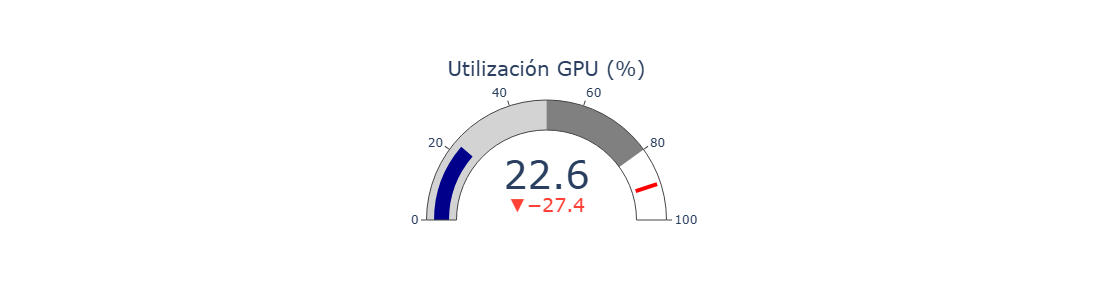

In [38]:
if history:
    # Extraer métricas de GPU usando la función del dashboard
    gpu_metrics = extract_gpu_metrics(history)
    
    print("=" * 70)
    print("🎮 MÉTRICAS DE GPU")
    print("=" * 70)
    
    if gpu_metrics['available']:
        print(f"✅ GPU utilizada: {gpu_metrics['device_name']}")
        print(f"📊 Memoria total: {gpu_metrics['total_memory_mb']:.2f} MB")
        print(f"📈 Memoria pico: {gpu_metrics['peak_memory_mb']:.2f} MB")
        print(f"📉 Memoria promedio: {gpu_metrics['avg_memory_mb']:.2f} MB")
        print(f"⚡ Utilización pico: {gpu_metrics['utilization_percent']:.2f}%")
        
        # Crear gráfica de uso de memoria
        fig = go.Figure()
        fig.add_trace(go.Indicator(
            mode="gauge+number+delta",
            value=gpu_metrics['utilization_percent'],
            title={'text': "Utilización GPU (%)"},
            delta={'reference': 50},
            gauge={'axis': {'range': [None, 100]},
                   'bar': {'color': "darkblue"},
                   'steps': [
                       {'range': [0, 50], 'color': "lightgray"},
                       {'range': [50, 80], 'color': "gray"}],
                   'threshold': {'line': {'color': "red", 'width': 4}, 'thickness': 0.75, 'value': 90}}
        ))
        fig.update_layout(height=300)
        fig.show()
    else:
        print("❌ GPU no disponible")
        print(f"💻 Dispositivo utilizado: {gpu_metrics['device_name']}")
    
    print("=" * 70)

## 📉 7. Gráfica de Convergencia

Visualizamos cómo evolucionan las métricas del modelo global durante el entrenamiento federado.

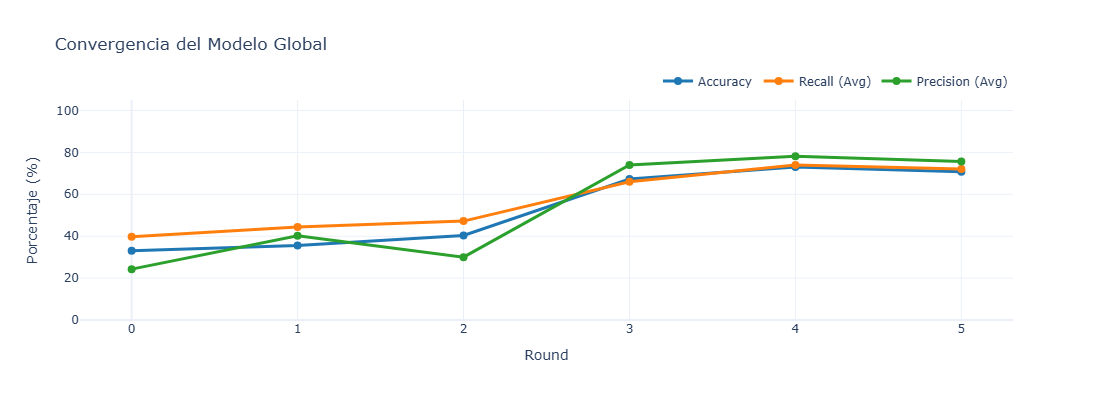

In [39]:
if history:
    # Crear gráfica de convergencia usando la función del dashboard
    plot_json = create_convergence_plot(history, metrics_type=demo_config['metrics_type'])
    
    if plot_json:
        import plotly.io as pio
        fig = pio.from_json(plot_json)
        fig.show()
    else:
        print("⚠️ No se pudo generar la gráfica de convergencia")

## 🏥 8. Comparación entre Hospitales

Comparamos el desempeño individual de cada hospital durante el entrenamiento.

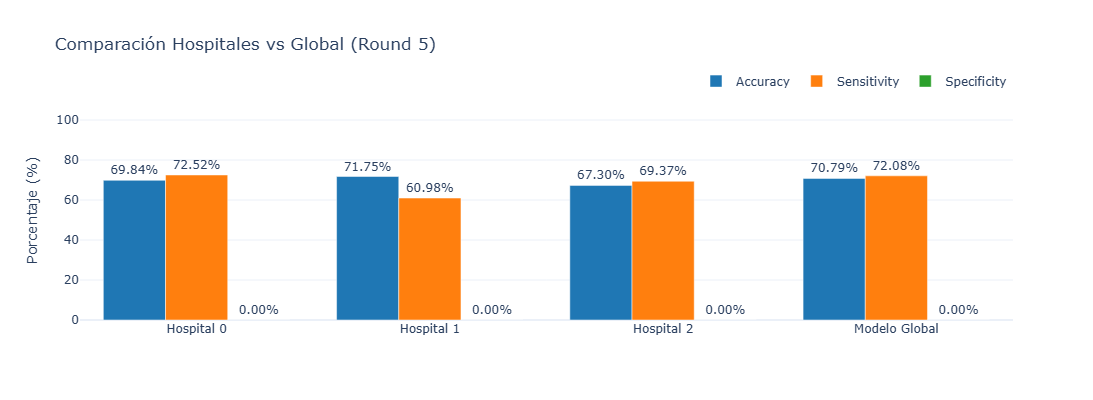

In [40]:
if history:
    # Crear gráfica de comparación entre hospitales
    plot_json = create_comparison_plot(history)
    
    if plot_json:
        import plotly.io as pio
        fig = pio.from_json(plot_json)
        fig.show()
    else:
        print("⚠️ No se pudo generar la gráfica de comparación")

## ⏱️ 9. Comparación de Tiempos de Entrenamiento

Analizamos el tiempo que tomó cada hospital en entrenar y refinar sus modelos.

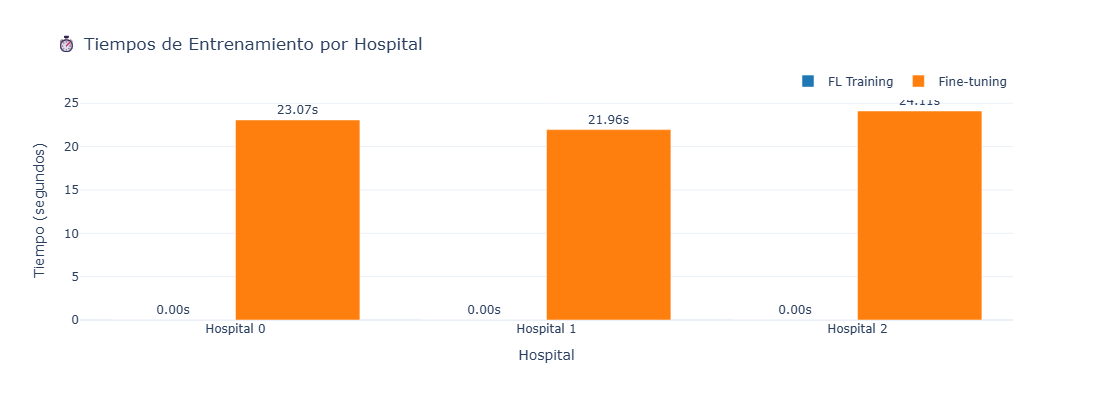

In [41]:
if history:
    # Crear gráfica de tiempos
    plot_json = create_timing_plot(history)
    
    if plot_json:
        import plotly.io as pio
        fig = pio.from_json(plot_json)
        fig.show()
    else:
        print("⚠️ No se pudo generar la gráfica de tiempos")

## 📊 10. Evolución del Modelo Global

Mostramos cómo evoluciona el modelo global comparado con los modelos locales de cada hospital.

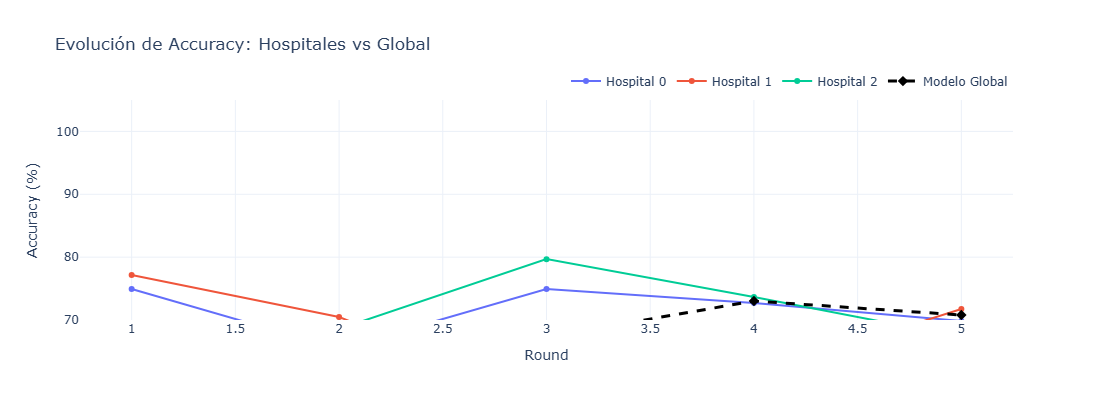

In [42]:
if history:
    # Crear gráfica de evolución
    plot_json = create_hospital_evolution_plot(history)
    
    if plot_json:
        import plotly.io as pio
        fig = pio.from_json(plot_json)
        fig.show()
    else:
        print("⚠️ No se pudo generar la gráfica de evolución")

## 🎯 11. Mejora con Fine-Tuning

Comparamos el modelo global vs los modelos refinados por cada hospital.

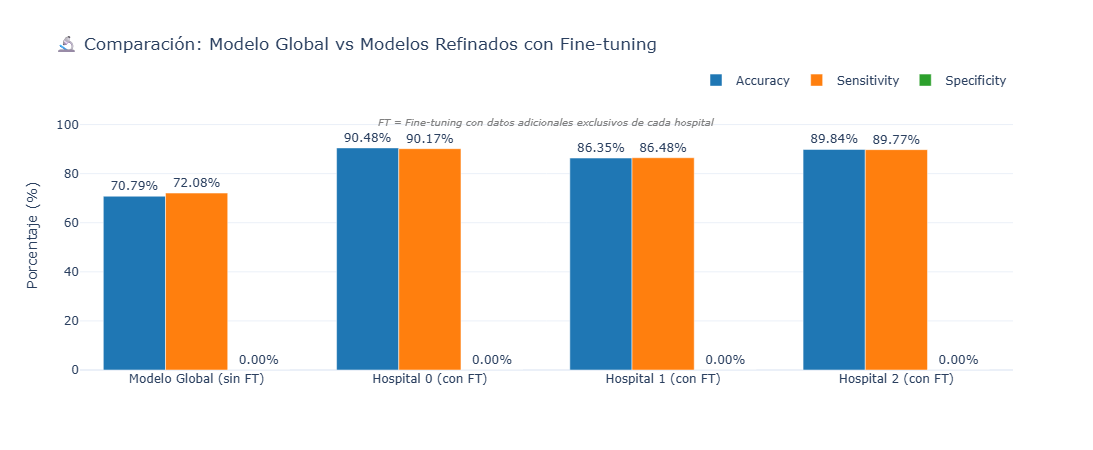

In [43]:
if history:
    # Crear gráfica de comparación global vs refinado
    plot_json = create_refined_comparison_plot(history)
    
    if plot_json:
        import plotly.io as pio
        fig = pio.from_json(plot_json)
        fig.show()
    else:
        print("⚠️ No se pudo generar la gráfica de comparación")

## 📋 12. Resumen Ejecutivo

Generamos un resumen completo de los resultados.

In [44]:
if history:
    # Calcular estadísticas generales
    fl_entries = [e for e in history if e.get('phase') == 'fl_training']
    ft_entries = [e for e in history if e.get('phase') == 'fine_tuning']
    
    initial_acc = fl_entries[0]['global_metrics']['accuracy'] * 100 if fl_entries else 0
    final_acc = fl_entries[-1]['global_metrics']['accuracy'] * 100 if fl_entries else 0
    improvement = final_acc - initial_acc
    
    print("=" * 70)
    print("📊 RESUMEN EJECUTIVO")
    print("=" * 70)
    print(f"\n🎯 Demo: {demo_config['name']}")
    print(f"📝 Descripción: {demo_config['description']}")
    print(f"\n📈 ACCURACY:")
    print(f"  Inicial: {initial_acc:.2f}%")
    print(f"  Final (Global): {final_acc:.2f}%")
    print(f"  Mejora: +{improvement:.2f}%")
    
    if ft_entries:
        refined_models = ft_entries[-1].get('refined_models', [])
        if refined_models:
            avg_refined = sum(m['accuracy'] for m in refined_models) / len(refined_models) * 100
            max_refined = max(m['accuracy'] for m in refined_models) * 100
            print(f"\n🏥 FINE-TUNING:")
            print(f"  Accuracy promedio refinado: {avg_refined:.2f}%")
            print(f"  Accuracy máximo refinado: {max_refined:.2f}%")
            print(f"  Mejora promedio vs global: +{avg_refined - final_acc:.2f}%")
    
    # Tiempos
    if ft_entries and 'timing' in ft_entries[-1]:
        timing = ft_entries[-1]['timing']
        fl_time = timing.get('fl_training_time', 0)
        ft_time = timing.get('finetune_total_time', 0)
        total_time = fl_time + ft_time
        
        print(f"\n⏱️ TIEMPOS:")
        print(f"  FL Training: {fl_time:.2f}s ({fl_time/60:.2f} min)")
        print(f"  Fine-Tuning: {ft_time:.2f}s ({ft_time/60:.2f} min)")
        print(f"  Total: {total_time:.2f}s ({total_time/60:.2f} min)")
    
    # GPU
    gpu_metrics = extract_gpu_metrics(history)
    if gpu_metrics['available']:
        print(f"\n🎮 GPU:")
        print(f"  Dispositivo: {gpu_metrics['device_name']}")
        print(f"  Memoria pico: {gpu_metrics['peak_memory_mb']:.2f} MB")
        print(f"  Utilización: {gpu_metrics['utilization_percent']:.2f}%")
    else:
        print(f"\n💻 Hardware: {gpu_metrics['device_name']}")
    
    print("\n" + "=" * 70)
    print("✅ Análisis completado")
    print("=" * 70)

📊 RESUMEN EJECUTIVO

🎯 Demo: Breast Ultrasound (Images)
📝 Descripción: Clasificación multiclase con imágenes de ultrasonido

📈 ACCURACY:
  Inicial: 33.02%
  Final (Global): 70.79%
  Mejora: +37.78%

🏥 FINE-TUNING:
  Accuracy promedio refinado: 88.89%
  Accuracy máximo refinado: 90.48%
  Mejora promedio vs global: +18.10%

⏱️ TIEMPOS:
  FL Training: 0.00s (0.00 min)
  Fine-Tuning: 102.51s (1.71 min)
  Total: 102.51s (1.71 min)

🎮 GPU:
  Dispositivo: NVIDIA GeForce RTX 2050
  Memoria pico: 926.00 MB
  Utilización: 22.61%

✅ Análisis completado


---

## 💡 Próximos Pasos

1. **Cambiar de demo**: Modifica `DEMO_TYPE = 'cancer'` en la celda 2 para ver el otro demo
2. **Explorar datos crudos**: Accede al objeto `history` directamente para análisis personalizados
3. **Dashboard interactivo**: Ejecuta `python dashboard_flask_cancer.py` para ver el dashboard web completo

**Archivos relacionados:**
- `dashboard_flask_cancer.py`: Dashboard Flask
- `fl_ultrasound_images.py`: Entrenamiento con imágenes
- `nvflare_breast_cancer_v2.py`: Entrenamiento con datos tabulares
- `training_history_*.json`: Resultados guardados

---

## 🚀 Re-entrenar con tu propia GPU (NVFLARE)

Este proyecto incluye los scripts de entrenamiento originales en la carpeta `training/`. Puedes re-entrenar los modelos con tus propios datos o GPU.

### Arquitectura FL implementada

El código sigue el patrón **NVFLARE** (NVIDIA Federated Learning Application Runtime Environment) simulando los tres roles del framework:

```
training/
├── nvflare_breast_cancer_v2.py   ← Demo cancer (datos tabulares)
├── fl_ultrasound_images.py       ← Demo ultrasonido (imágenes + ResNet18)
└── nvflare_config/
    ├── breast_cancer_net.py      ← Arquitectura de la red neuronal
    ├── breast_cancer_trainer.py  ← Lógica de entrenamiento FL
    ├── config_fed_client.json    ← Configuración del cliente NVFLARE
    └── config_fed_server.json    ← Configuración del servidor NVFLARE
```

### Componentes clave del código

| Clase / Función | Archivo | Rol NVFLARE |
|---|---|---|
| `BreastCancerClient` | `nvflare_breast_cancer_v2.py` | `FLComponent` — cliente de cada hospital |
| `FLServer` | `nvflare_breast_cancer_v2.py` | Servidor FL — agrega gradientes con FedAvg |
| `UltrasoundClient` | `fl_ultrasound_images.py` | Cliente con ResNet18 preentrenado |
| `aggregate_models()` | ambos scripts | Implementa **FedAvg** (Federated Averaging) |
| `train_fl()` | ambos scripts | Ronda local de entrenamiento por hospital |
| `finetune()` | ambos scripts | Fine-tuning local post-agregación |

### Flujo de entrenamiento FL

```
Ronda 1..N:
  ┌─ Hospital A: train_fl() → pesos locales ─┐
  ├─ Hospital B: train_fl() → pesos locales ──┼──► FLServer.aggregate() [FedAvg] ──► Modelo Global
  └─ Hospital C: train_fl() → pesos locales ─┘

Post-entrenamiento:
  Hospital A: finetune(modelo_global) ──► Modelo personalizado A
  Hospital B: finetune(modelo_global) ──► Modelo personalizado B
  Hospital C: finetune(modelo_global) ──► Modelo personalizado C
```

### Instalación para re-entrenar con GPU

```bash
# 1. Instalar dependencias
pip install -r requirements.txt

# Para GPU con CUDA 11.8:
pip install torch torchvision --index-url https://download.pytorch.org/whl/cu118

# Para GPU con CUDA 12.1:
pip install torch torchvision --index-url https://download.pytorch.org/whl/cu121

# 2. Verificar GPU disponible
python -c "import torch; print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU only')"
```

### Ejecutar el entrenamiento

```bash
# Desde la raíz del proyecto

# Demo 1: Breast Cancer (tabular) — ~2-5 min en CPU, ~30s en GPU
python training/nvflare_breast_cancer_v2.py

# Demo 2: Breast Ultrasound (imágenes ResNet18) — requiere GPU recomendada
python training/fl_ultrasound_images.py
```

Los resultados se guardan automáticamente en:
- `training_history_cancer_nvflare.json`
- `training_history_ultrasound_nvflare.json`

Una vez regenerados, ejecuta este notebook desde la celda 1 para visualizar los nuevos resultados.